<a href="https://colab.research.google.com/github/ibonfilrivera/Curso_Python_FQ/blob/main/Curso_Python_Sesion_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Curso introductorio de Python**

## **Facultad de Química**

### **Departamento de Física y Química Teórica**

Elaboró: Iván Bonfil, Rafael Rodriguez y Roberto Rojas

Fecha: 25 de abril de 2026

---

# **Sesión 3: Librerías y análisis de datos**

En esta sesión aprenderemos a emplear librerías especializadas de Python para realizar análisis de datos exploratorio.

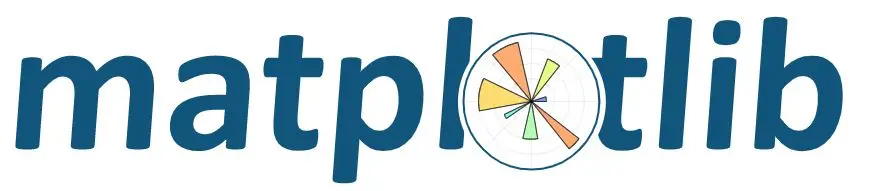

# Importar librerías

Introducción al tema

In [ ]:
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

# Math y Scipy

Dos de las librerías en Python que contienen varias funciones para el trabajo matemático en general son Math y Scipy. Math nos permite el acceso a varias funciones y constantes matemáticas.

In [ ]:
import math

#Seno
seno = math.sin(math.pi)
print(seno)

#Coseno
cosen = math.cos(math.pi/3)
print(cosen)

#Raíz cuadrada
print(math.sqrt(100))

#Logaritmos
print(math.log(math.e))
print(math.log10(100))
print(math.log2(8))

1.2246467991473532e-16
0.5000000000000001
10.0
1.0
2.0
3.0


In [ ]:
from sympy import *

x = symbols("x")
diff(x ** 2)
integrate(x ** 2)

x**3/3

En el caso de scipy incluye varias librerías con métodos numéricos, estadísticos, entre otros de utilidad en el trabajo de datos en ciencia. Veamos por ejemplo, cómo hacer análisis estadísticos con `scipy.stats`

Digamos que tenemos la siguiente curva de calibración de absorbancia y concentraciones:

`concentraciones = [0.0, 2.0, 4.0, 6.0, 8.0, 10.0]`

`absorbancias = [0.012, 0.225, 0.451, 0.645, 0.852, 1.058]`

In [ ]:
from scipy.stats import *

concentraciones = [0.0, 2.0, 4.0, 6.0, 8.0, 10.0]
absorbancias = [0.012, 0.225, 0.451, 0.645, 0.852, 1.058]

#Análisis estadístico descriptivo general:

resumen = describe(concentraciones)
print(resumen)

#Regresión lineal

res_lin = linregress(concentraciones, absorbancias)
print(res_lin)

DescribeResult(nobs=np.int64(6), minmax=(np.float64(0.0), np.float64(10.0)), mean=np.float64(5.0), variance=np.float64(13.999999999999998), skewness=np.float64(0.0), kurtosis=np.float64(-1.2685714285714282))
LinregressResult(slope=np.float64(0.10435714285714284), intercept=np.float64(0.018714285714285905), rvalue=np.float64(0.9998081620473488), pvalue=np.float64(5.519917012512049e-08), stderr=np.float64(0.001022202504000253), intercept_stderr=np.float64(0.0061897435463914175))


También con la función curve_fit de scipy.optimize podemos buscar los parámetros de cualquier tipo de regresión.

In [ ]:
from scipy.optimize import curve_fit

def quad_func(x, a, b, c):
  return a * x ** 2 + b * x + c

curve_fit(quad_func, concentraciones, absorbancias)

(array([-0.00049554,  0.1093125 ,  0.01210714]),
 array([[ 8.14134195e-08, -8.14134166e-07,  1.08551246e-06],
        [-8.14134166e-07,  8.83606886e-06, -1.43287618e-05],
        [ 1.08551246e-06, -1.43287618e-05,  3.99468524e-05]]))

También en scipy.optimize tenemos funciones para resolver ecuaciones por métodos numéricos (`fsolve`) y también buscar puntos críticos (`minimize`).

In [ ]:
from scipy.optimize import fsolve, minimize

def poli_ejemplo(x):
  return (x + 2)**2 - 4

sols = fsolve(poli_ejemplo, -3)
print(sols)

pc_min = minimize(poli_ejemplo, 3)
print(pc_min)

[-4.]
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -4.0
        x: [-2.000e+00]
      nit: 3
      jac: [ 0.000e+00]
 hess_inv: [[ 5.000e-01]]
     nfev: 8
     njev: 4


## Ejercicio:

A partir de los siguientes datos de concentración y tiempo:

`tiempo = [0, 10, 20, 30, 40, 50]`

`concentración = [1.000, 0.607, 0.368, 0.223, 0.135, 0.082]`

Y las ecuaciones integradas de velocidad para orden 0, 1 y 2:

Orden 0: $$[A] = -kt + [A]_0$$
Orden 1: $$\ln[A] = -kt + \ln[A]_0$$
Orden 2: $$\frac{1}{[A]} = kt + \frac{1}{[A]_0}$$

Determine qué regresión lineal describe mejor los datos experimentales.

In [ ]:
tiempo = [0, 10, 20, 30, 40, 50]
conc = [1.000, 0.607, 0.368, 0.223, 0.135, 0.082]

lncon = []
inv_conc = []

for i in conc:
  lncon.append(math.log(i))
  inv_conc.append(1/i)

orden_cero = linregress(tiempo, conc)
orden_uno = linregress(tiempo, lncon)
orden_dos = linregress(tiempo, inv_conc)

print(orden_cero)
print(orden_uno)
print(orden_dos)

LinregressResult(slope=np.float64(-0.017574285714285712), intercept=np.float64(0.8418571428571429), rvalue=np.float64(-0.9440097308303824), pvalue=np.float64(0.004614603128402038), stderr=np.float64(0.0030709780400466824), intercept_stderr=np.float64(0.09297847750372958))
LinregressResult(slope=np.float64(-0.050045295323318396), intercept=np.float64(0.0006325716630506406), rvalue=np.float64(-0.9999996368729984), pvalue=np.float64(1.9779180497261659e-13), stderr=np.float64(2.1324440670178978e-05), intercept_stderr=np.float64(0.0006456295034599833))
LinregressResult(slope=np.float64(0.2143497320935344), intercept=np.float64(-0.4501312933883126), rvalue=np.float64(0.9439820800038482), pvalue=np.float64(0.004619118718403516), stderr=np.float64(0.03746612842788914), intercept_stderr=np.float64(1.1343433700136065))


# Numpy

En la clase anterior estuvimos trabajando con listas en python, en esta clase comenzaremos introduciendo una estructura similar, pero más eficiente para el uso en operaciones matemáticas.

Veamos un ejemplo de cómo una misma operación puede acelerarse con numpy:

In [ ]:
#Creemos una lista y un array con el cuadrado de los primeros números naturales hasta 10 000 000

lista = [i for i in range(10000000)]
array = np.array(lista)

res_lista = []
res_array = []

init_lista = time.time()
for i in lista:
    res_lista.append(i**2)
end_lista = time.time()

init_array = time.time()

res_array = array**2

end_array = time.time()

print("Resultado con lista: ", res_lista[:10])
print("Resultado con array: ", res_array[:10])
print("Tiempo de ejecución con lista: ", end_lista - init_lista)
print("Tiempo de ejecución con array: ", end_array - init_array)



Resultado con lista:  [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
Resultado con array:  [ 0  1  4  9 16 25 36 49 64 81]
Tiempo de ejecución con lista:  2.418877601623535
Tiempo de ejecución con array:  0.03174781799316406


Los arrays de numpy están diseñados para representar estructuras matemáticas como vectores, matrices, tensores ... y realizar las operaciones más comunes con ellos.

In [ ]:
# Definimos dos matrices genéricas de 2x2
matriz_A = np.array([[1, 2],
                     [3, 4]])

matriz_B = np.array([[5, 6],
                     [7, 8]])

# Multiplicación elemento a elemento (Hadamard product)
# Esto multiplica posición por posición, NO es multiplicación de matrices algebraicas
multiplicacion_elementos = matriz_A * matriz_B

# Multiplicación de matrices (Álgebra lineal)
# Filas por columnas
multiplicacion_matricial = np.dot(matriz_A, matriz_B)
# Alternativamente, usando el operador @
multiplicacion_matricial_alt = matriz_A @ matriz_B

print("Multiplicación Elemento a Elemento:\n", multiplicacion_elementos)
print("\nMultiplicación Matricial Correcta:\n", multiplicacion_matricial)

# Transposición de una matriz (intercambiar filas por columnas)
matriz_A_transpuesta = matriz_A.T
print("\nMatriz A Transpuesta:\n", matriz_A_transpuesta)

Multiplicación Elemento a Elemento:
 [[ 5 12]
 [21 32]]

Multiplicación Matricial Correcta:
 [[19 22]
 [43 50]]

Matriz A Transpuesta:
 [[1 3]
 [2 4]]


Estos al igual que las listas tienen un indexado y también pueden extraerse columnas completans empleando el llamado `slicing`

In [ ]:
arr = np.arange(9)

print(arr)
print(np.shape(arr))

arr = arr.reshape(3, 3)

print(arr)

print(arr[0])
print(arr[0][1])

print(arr[:,0])
print(arr[0, :])

arr[0, :] = [10,20,30]
print(arr)

arr[:, 0] = [1,2,3]
print(arr)

[0 1 2 3 4 5 6 7 8]
(9,)
[[0 1 2]
 [3 4 5]
 [6 7 8]]
[0 1 2]
1
[0 3 6]
[0 1 2]
[[10 20 30]
 [ 3  4  5]
 [ 6  7  8]]
[[ 1 20 30]
 [ 2  4  5]
 [ 3  7  8]]


Dentro de numpy también existe un un conjunto de funciones de álgebra lineal en el módulo `np.linalg`. Veamos algunas de las más comunes:



In [ ]:
determinante = np.linalg.det(matriz_A)

val_prop, vec_prop = np.linalg.eig(matriz_A)

print("Determinante de A: ", determinante)
print("Valores propios de A: ", val_prop)
print("Vectores propios de A: ", vec_prop)

Determinante de A:  -2.0000000000000004
Valores propios de A:  [-0.37228132  5.37228132]
Vectores propios de A:  [[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]


In [ ]:
matriz_A = np.array([
    [ 2,  1,  1],
    [ 1, -1,  2],
    [ 3,  2, -1]
])

# 2. Definimos el vector 'b' con los resultados (lado derecho)
# Nota: Puede ser un arreglo 1D simple, np.linalg.solve lo entiende perfectamente
vector_b = np.array([10, 5, 7])

# 3. Resolvemos el sistema
vector_x = np.linalg.solve(matriz_A, vector_b)

print("Solución del sistema: ", vector_x)

Solución del sistema:  [1. 4. 4.]


## Ejercicio 1:

Para rotar un vector en $\mathbb{R}²$ existe la llamada matriz de rotación, la cual al multiplicarla por el vector da como resultado el vector rotado. Esta matriz tiene la siguiente estructura:

$$R(\theta) = \begin{pmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{pmatrix}$$

Cree una función que acepte como entrada un vector y el ángulo a rotar, y devuelva el vector rotado esa cantidad de grados.

In [ ]:
import numpy as np

def rotar_vector(vector, angulo_grados):

    theta = np.radians(angulo_grados)

    matriz_rotacion = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    v = np.array(vector)

    vector_rotado = matriz_rotacion @ v

    return vector_rotado

vec_y = np.array([0, 1])
vec_x = np.array([1, 0])

print(rotar_vector(vec_y, 90))

[-1.000000e+00  6.123234e-17]


## Ejercicio 2

Ahora creemos una función que a partir de los coeficientes de un sistema de ecuaciones de 2x2 y el vector de resultados, calcule el valor de las variables empleando el método de Kramer. Este se define para un sistema:

$$\begin{align*}
ax + by &= e \\
cx + dy &= f
\end{align*}$$

Como:

$$x = \frac{\Delta_x}{\Delta}, \quad y = \frac{\Delta_y}{\Delta}$$

Donde:

$$\Delta = \begin{vmatrix} a & b \\ c & d \end{vmatrix} = ad - bc$$
$$\Delta_x = \begin{vmatrix} e & b \\ f & d \end{vmatrix} = ed - bf$$
$$\Delta_y = \begin{vmatrix} a & e \\ c & f \end{vmatrix} = af - ce$$

In [ ]:
def resolver_cramer_2x2(matriz_A, vector_b):

    delta = np.linalg.det(matriz_A)

    matriz_Ax = matriz_A.copy()
    matriz_Ay = matriz_A.copy()

    matriz_Ax[:, 0] = vector_b
    matriz_Ay[:, 1] = vector_b

    delta_x = np.linalg.det(matriz_Ax)
    delta_y = np.linalg.det(matriz_Ay)

    x = delta_x / delta
    y = delta_y / delta

    return np.array([x, y])

A = np.array([
    [3,  2],
    [4, -1]
])

b = np.array([12, 5])

solucion_cramer = resolver_cramer_2x2(A, b)

solucion_numpy = np.linalg.solve(A, b)

print(f"Solución usando Cramer: {np.round(solucion_cramer, 4)}")
print(f"Solución usando np.linalg.solve: {np.round(solucion_numpy, 4)}")

--- RESULTADOS ---
Solución usando Cramer: [2. 3.]
Solución usando np.linalg.solve: [2. 3.]


# Matplotlib

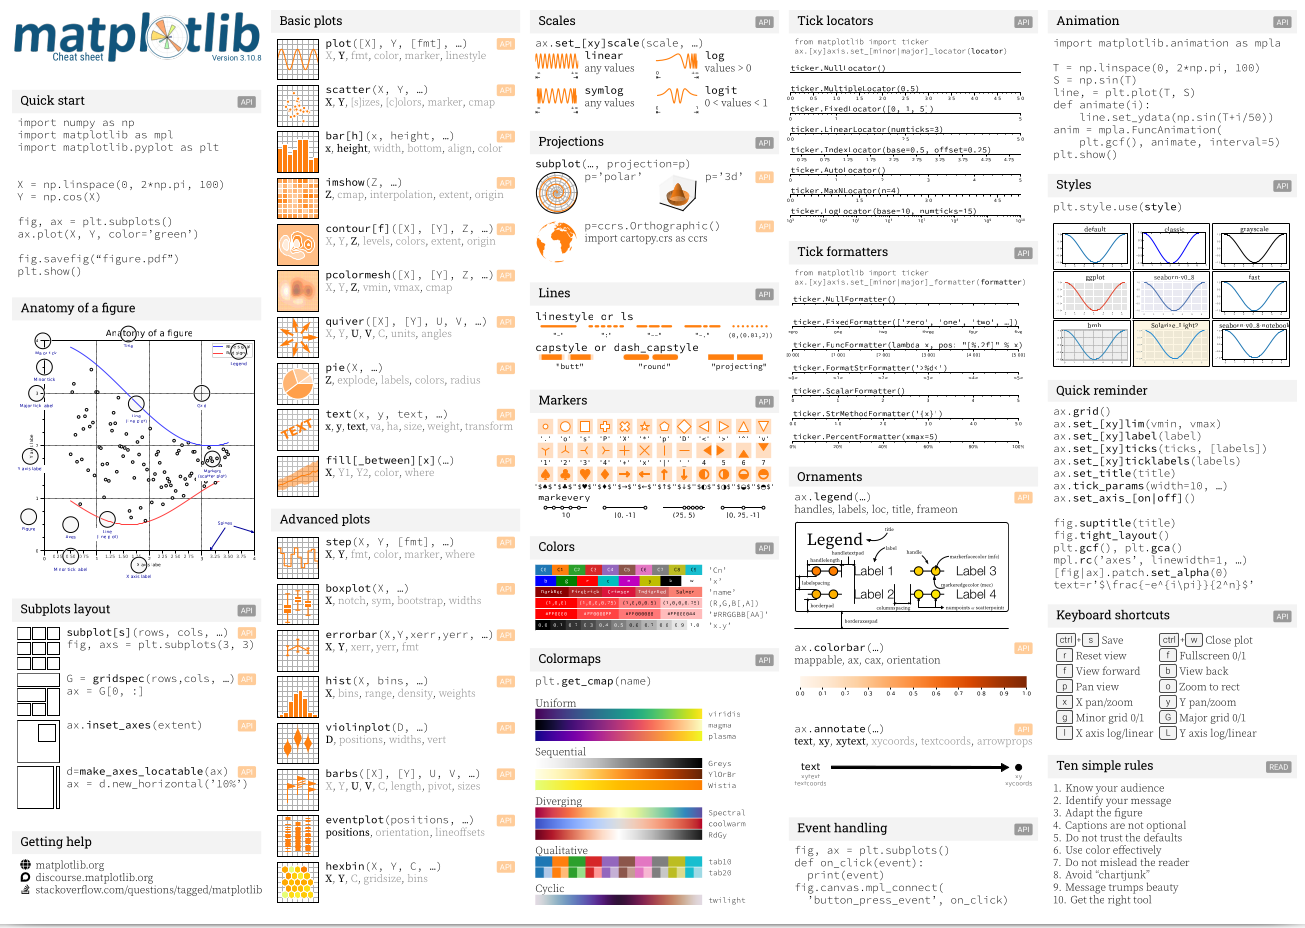

Como vemos en el resumen MatPlotLib, este nos permite realizar diferentes grupos de gráficos. Intentemos realizar estos gráficos para cada uno de los ejemplos que aparecen.

# Pandas

Para el análisis de grandes cantidades de datos una de las librerías más utilizadas es Pandas. Esta no solo permite leer diferentes formatos de datos, también permite el análisis y facilita graficar de forma sencilla estos datos.

In [ ]:
import pandas as pd

df = pd.read_csv("./curated-solubility-dataset.csv")
df.head()

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,...,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,...,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934


Hágamos algunos análisis preliminares de estos datos:

In [ ]:
df.describe()

,Solubility,SD,Ocurrences,MolWt,MolLogP,MolMR,HeavyAtomCount,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
count,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000,9982.000000
mean,-2.889909,0.067449,1.378081,266.665946,1.979167,66.794594,17.374674,3.486776,1.108595,5.196955,4.073031,94.243438,1.068323,0.292627,0.447606,1.515929,62.458601,108.912586,2.392199,467.336782
std,2.368154,0.234702,1.023476,184.179024,3.517738,46.523021,12.241536,3.498203,1.488973,4.736275,5.646925,64.748563,1.309427,0.879599,1.054667,1.644334,63.348307,76.462726,1.091123,546.631696
min,-13.171900,0.000000,1.000000,9.012000,-40.873200,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.504228,-0.000004,0.000000
25%,-4.326325,0.000000,1.000000,162.276000,0.619750,40.602475,11.000000,2.000000,0.000000,3.000000,1.000000,58.000000,0.000000,0.000000,0.000000,0.000000,26.300000,66.623721,2.004357,163.243343
50%,-2.618173,0.000000,1.000000,228.682000,1.949220,58.633400,15.000000,3.000000,1.000000,4.000000,3.000000,82.000000,1.000000,0.000000,0.000000,1.000000,50.720000,93.299873,2.539539,351.640433
75%,-1.209735,0.000000,1.000000,320.436000,3.419030,81.938000,21.000000,4.000000,2.000000,6.000000,5.000000,112.000000,2.000000,0.000000,1.000000,2.000000,80.390000,129.118374,3.032456,606.562848
max,2.137682,3.870145,38.000000,5299.456000,68.541140,1419.351700,388.000000,86.000000,26.000000,89.000000,141.000000,2012.000000,35.000000,30.000000,30.000000,36.000000,1214.340000,2230.685124,7.517310,20720.267708


In [ ]:
df[df["MolWt"] < 50]

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
30,A-45,hydroxylamine,"InChI=1S/H3NO/c1-2/h2H,1H2",AVXURJPOCDRRFD-UHFFFAOYSA-N,NO,-0.763034,0.861298,7,G4,33.030,...,0.0,14.0,0.0,0.0,0.0,0.0,46.25,12.462472,1.000000,2.000000
74,A-119,fluoromethane,InChI=1S/CH3F/c1-2/h1H3,NBVXSUQYWXRMNV-UHFFFAOYSA-N,CF,-0.175874,0.000000,1,G1,34.033,...,0.0,14.0,0.0,0.0,0.0,0.0,0.00,12.904786,1.000000,2.000000
143,A-238,magnesium,InChI=1S/Mg/q+2,JLVVSXFLKOJNIY-UHFFFAOYSA-N,[Mg++],-2.402069,0.552079,3,G4,24.305,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,23.638374,0.000000,0.000000
206,A-356,ethanol,"InChI=1S/C2H6O/c1-2-3/h3H,2H2,1H3",LFQSCWFLJHTTHZ-UHFFFAOYSA-N,CCO,1.233668,0.096863,3,G5,46.069,...,0.0,20.0,0.0,0.0,0.0,0.0,20.23,19.898427,1.632993,2.754888
310,A-516,ethane,InChI=1S/C2H6/c1-2/h1-2H3,OTMSDBZUPAUEDD-UHFFFAOYSA-N,CC,-2.691382,0.599587,5,G4,30.070,...,0.0,14.0,0.0,0.0,0.0,0.0,0.00,15.104193,1.000000,0.000000
419,A-719,ammonia,InChI=1S/H3N/h1H3,QGZKDVFQNNGYKY-UHFFFAOYSA-N,N,1.451807,0.029165,4,G5,17.031,...,0.0,8.0,0.0,0.0,0.0,0.0,35.00,7.504228,0.000000,0.000000
536,A-960,methoxymethane,InChI=1S/C2H6O/c1-3-2/h1-2H3,LCGLNKUTAGEVQW-UHFFFAOYSA-N,COC,0.884366,0.444405,2,G3,46.069,...,0.0,20.0,0.0,0.0,0.0,0.0,9.23,20.217738,1.632993,2.754888
567,A-1007,methanidylidyneoxidanium,InChI=1S/CO/c1-2,UGFAIRIUMAVXCW-UHFFFAOYSA-N,[C-]#[O+],-2.928799,0.000000,1,G1,28.010,...,0.0,10.0,0.0,0.0,0.0,0.0,19.90,12.619698,3.000000,6.754888
1034,A-1790,acetylene,InChI=1S/C2H2/c1-2/h1-2H,HSFWRNGVRCDJHI-UHFFFAOYSA-N,C#C,-1.336426,0.813213,2,G2,26.038,...,0.0,10.0,0.0,0.0,0.0,0.0,0.00,14.103419,3.000000,4.754888
1111,A-1902,peroxol,InChI=1S/H2O2/c1-2/h1-2H,MHAJPDPJQMAIIY-UHFFFAOYSA-N,OO,0.468342,0.000000,1,G1,34.014,...,0.0,14.0,0.0,0.0,0.0,0.0,40.46,11.892072,1.000000,0.000000


In [ ]:
df[(df["MolWt"] < 500) & (df["MolLogP"] < 5)]

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.000000,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.000000,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.000000,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782,202.661065
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.000000,1,G1,422.525,...,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427,769.899934
5,A-10,vinyltoluene,"InChI=1S/C9H10/c1-3-9-6-4-5-8(2)7-9/h3-7H,1H2,2H3",JZHGRUMIRATHIU-UHFFFAOYSA-N,Cc1cccc(C=C)c1,-3.123150,0.000000,1,G1,118.179,...,1.0,46.0,1.0,0.0,0.0,1.0,0.00,55.836626,3.070761,211.033225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9976,I-83,sulindac_form_II,InChI=1S/C20H17FO3S/c1-12-17(9-13-3-6-15(7-4-1...,MLKXDPUZXIRXEP-RQZCQDPDSA-N,CC1=C(CC(O)=O)c2cc(F)ccc2C\1=C\c1ccc(cc1)S(C)=O,-4.500000,0.410000,2,G3,356.418,...,4.0,128.0,2.0,0.0,1.0,3.0,54.37,147.518542,2.101112,939.913669
9977,I-84,tetracaine,InChI=1S/C15H24N2O2/c1-4-5-10-16-14-8-6-13(7-9...,GKCBAIGFKIBETG-UHFFFAOYSA-N,C(c1ccc(cc1)NCCCC)(=O)OCCN(C)C,-3.010000,0.000000,1,G1,264.369,...,8.0,106.0,1.0,0.0,0.0,1.0,41.57,115.300645,2.394548,374.236893
9978,I-85,tetracycline,InChI=1S/C22H24N2O8/c1-21(31)8-5-4-6-11(25)12(...,OFVLGDICTFRJMM-WESIUVDSSA-N,OC1=C(C(C2=C(O)[C@@](C(C(C(N)=O)=C(O)[C@H]3N(C...,-2.930000,0.000000,1,G1,444.440,...,2.0,170.0,1.0,0.0,3.0,4.0,181.62,182.429237,2.047922,1148.584975
9979,I-86,thymol,InChI=1S/C10H14O/c1-7(2)9-5-4-8(3)6-10(9)11/h4...,MGSRCZKZVOBKFT-UHFFFAOYSA-N,c1(cc(ccc1C(C)C)C)O,-2.190000,0.019222,3,G5,150.221,...,1.0,60.0,1.0,0.0,0.0,1.0,20.23,67.685405,3.092720,251.049732


## Ejercicio

En el diseño de fármacos, la Regla de los 5 de Lipinski se utiliza para evaluar si un compuesto químico tiene propiedades fisicoquímicas que harían probable que sea un fármaco activo por vía oral en humanos.La regla estipula que un candidato ideal no debe violar las siguientes condiciones:
* Peso Molecular (MW) $\le 500$ g/mol.
* Coeficiente de partición octanol-agua (LogP) $\le 5$.
* Número de donadores de enlaces de hidrógeno (HBD) $\le 5$.
* Número de aceptores de enlaces de hidrógeno (HBA) $\le 10$.

Encuentra qué moléculas cumplen con estas características en la base datos que estamos trabajando.

In [ ]:
df[(df["MolWt"] < 500) & (df["MolLogP"] < 5) & (df["NumHAcceptors"] < 5) & (df["NumHDonors"] < 10)]


,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.000000,1,G1,392.510,...,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.000000,1,G1,169.183,...,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.000000,1,G1,140.569,...,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782,202.661065
5,A-10,vinyltoluene,"InChI=1S/C9H10/c1-3-9-6-4-5-8(2)7-9/h3-7H,1H2,2H3",JZHGRUMIRATHIU-UHFFFAOYSA-N,Cc1cccc(C=C)c1,-3.123150,0.000000,1,G1,118.179,...,1.0,46.0,1.0,0.0,0.0,1.0,0.00,55.836626,3.070761,211.033225
6,A-11,3-(3-ethylcyclopentyl)propanoic acid,InChI=1S/C10H18O2/c1-2-8-3-4-9(7-8)5-6-10(11)1...,WVRFSLWCFASCIS-UHFFFAOYSA-N,CCC1CCC(CCC(O)=O)C1,-3.286116,0.000000,1,G1,170.252,...,4.0,70.0,0.0,1.0,1.0,1.0,37.30,73.973655,2.145839,153.917569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9970,I-74,quinine,InChI=1S/C20H24N2O2/c1-3-13-12-22-9-7-14(13)10...,LOUPRKONTZGTKE-LFDRZELQSA-N,[H]C1(CN2CCC1C[C@@]2([H])[C@H](O)C1=CC=NC2=C1C...,-2.790000,0.000000,1,G1,324.424,...,4.0,126.0,2.0,3.0,3.0,5.0,45.59,142.313426,1.687085,760.387301
9976,I-83,sulindac_form_II,InChI=1S/C20H17FO3S/c1-12-17(9-13-3-6-15(7-4-1...,MLKXDPUZXIRXEP-RQZCQDPDSA-N,CC1=C(CC(O)=O)c2cc(F)ccc2C\1=C\c1ccc(cc1)S(C)=O,-4.500000,0.410000,2,G3,356.418,...,4.0,128.0,2.0,0.0,1.0,3.0,54.37,147.518542,2.101112,939.913669
9977,I-84,tetracaine,InChI=1S/C15H24N2O2/c1-4-5-10-16-14-8-6-13(7-9...,GKCBAIGFKIBETG-UHFFFAOYSA-N,C(c1ccc(cc1)NCCCC)(=O)OCCN(C)C,-3.010000,0.000000,1,G1,264.369,...,8.0,106.0,1.0,0.0,0.0,1.0,41.57,115.300645,2.394548,374.236893
9979,I-86,thymol,InChI=1S/C10H14O/c1-7(2)9-5-4-8(3)6-10(9)11/h4...,MGSRCZKZVOBKFT-UHFFFAOYSA-N,c1(cc(ccc1C(C)C)C)O,-2.190000,0.019222,3,G5,150.221,...,1.0,60.0,1.0,0.0,0.0,1.0,20.23,67.685405,3.092720,251.049732


# Librerías adicionales

RdKit, Etc.

Para terminar trabajaremos un poco con RDKit, que es una libería para manipular sustancias químicas.

In [ ]:
!pip install rdkit
from rdkit import Chem
from rdkit.Chem import MolFromSmiles
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

In [ ]:
mol_smiles = df["SMILES"][0]
print(mol_smiles)

[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C


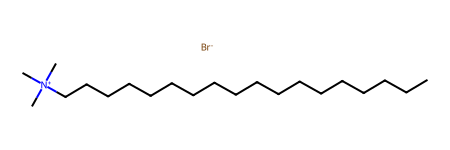

In [ ]:
mol = MolFromSmiles(mol_smiles)
mol

In [ ]:
df["Mols"] = df["SMILES"].apply(MolFromSmiles)
df.head()

[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not removing hydrogen atom without neighbors
[21:21:00] WARNING: not r

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT,Mols
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,...,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334,<rdkit.Chem.rdchem.Mol object at 0x7acbced12f10>
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,...,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248,<rdkit.Chem.rdchem.Mol object at 0x7acbced12f80>
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,...,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065,<rdkit.Chem.rdchem.Mol object at 0x7acbced12c70>
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,...,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666,<rdkit.Chem.rdchem.Mol object at 0x7acbced13610>
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,...,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934,<rdkit.Chem.rdchem.Mol object at 0x7acbced13a70>


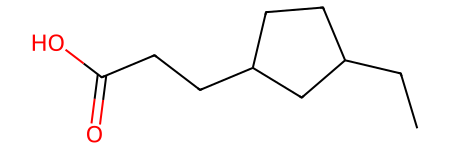

In [ ]:
x = df["Mols"][6]
x

In [ ]:
from types import NoneType
def tiene_benceno(mol):
    frag = Chem.MolFromSmarts("c1ccccc1")
    if type(mol) == NoneType:
        return None
    elif mol.HasSubstructMatch(frag) == True:
          return True
    else:
        return False

df["Mols"].apply(lambda m: tiene_benceno(m))

,Mols
0,False
1,True
2,True
3,True
4,True
...,...
9977,True
9978,True
9979,True
9980,True
